## **PART 1 -- Inference from samples**

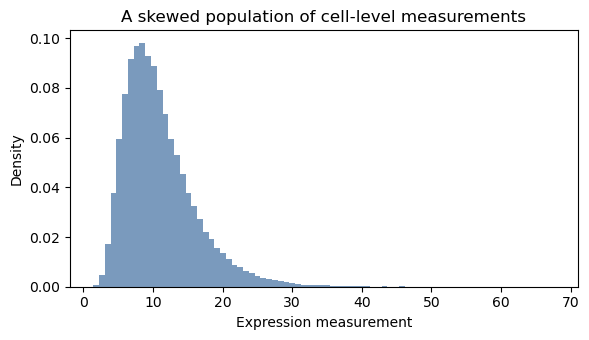

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(375)
population = rng.lognormal(mean=2.3, sigma=0.45, size=100_000)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(population, bins=80, density=True, color="#4E79A7", alpha=0.75)
ax.set_xlabel("Expression measurement")
ax.set_ylabel("Density")
ax.set_title("A skewed population of cell-level measurements")
plt.tight_layout()


#### **Question 1:** Sampling variability and confidence intervals
1. Describe the shape of the population distribution. Does it look Gaussian?
2. For each 𝑛 in sample_sizes = [5, 20, 100], draw 5,000 independent samples from population,
store their means, and plot the three sampling distributions. How do their centers and spreads
change as 𝑛 increases?
3. Explain how the simulation illustrates the Central Limit Theorem. Compare the simulated standard
deviations with 𝑠/√𝑛, and explain how standard errors change when sample size is multiplied by
four.
4. Does the Central Limit Theorem claim that individual measurements become Gaussian as 𝑛 increases?
Explain the distinction.

Use the following seven control-cell measurements to examine uncertainty in a mean:
𝑦𝐶 = (8.8, 9.6, 10.2, 10.7, 11.0, 11.4, 12.1).
5. Calculate the sample mean, sample standard deviation, estimated standard error, and an approximate 95% confidence interval using 𝑦 ± 𝑡0.975,𝑛−1 s/sqrt(n).
6. In your own words, explain what 95% confidence means for the procedure that produced this interval.
What would be an incorrect interpretation?
7. Repeat the interval calculation using a much larger simulated sample from population. Why is the
larger-sample interval generally narrower? Name two other factors that affect interval width, and
distinguish uncertainty in the mean from variability among observations.

The simulated standard deviation for n = 5 is 2.291 while the standard error is 2.336, a difference of 1.94%
The simulated standard deviation for n = 20 is 1.175 while the standard error is 1.168, a difference of 0.57%
The simulated standard deviation for n = 100 is 0.523 while the standard error is 0.522, a difference of 0.14%


Sample mean: 10.54
Sample standard deviation: 1.11
Estimated standard error: 0.42
The 95% confidence interval is: [9.51, 11.57]
The 95% confidence interval for a sample of 1000 from the population is: [10.88, 11.73]


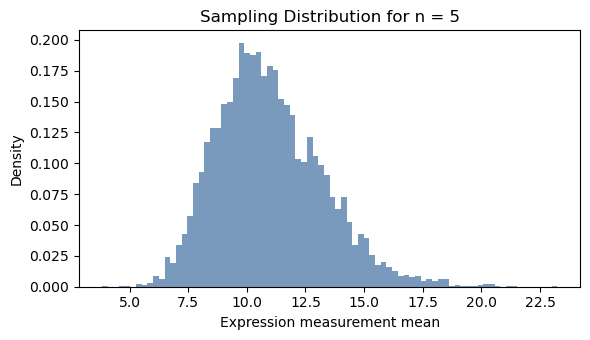

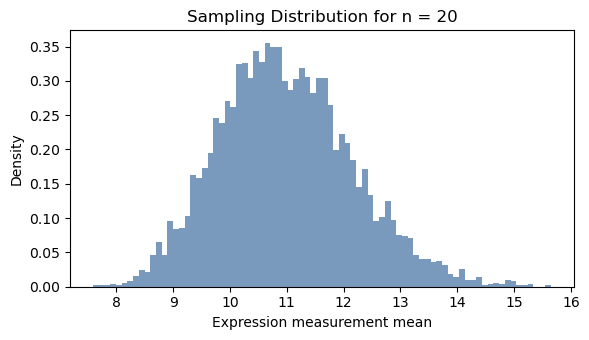

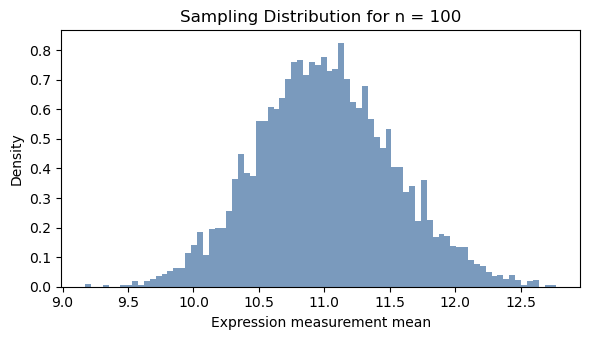

In [ ]:
###
# Answers
###

#1. 
# The plot looks to unimodal and right skewed. It does not look Gaussian since Gaussian distributions are symmetric and bell-shaped, while this distrbution is not symmetric and has greater density in lower values.

#2. 
sample_sizes = [5, 20, 100]
for n in sample_sizes:

    s_means = []

    for i in range(5000):
        sample = rng.choice(population, size=n, replace=True)
        s_means.append(sample.mean())

    s_means = np.array(s_means)

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(s_means, bins=80, density=True, color="#4E79A7", alpha=0.75)
    ax.set_xlabel("Expression measurement mean")
    ax.set_ylabel("Density")
    ax.set_title(f"Sampling Distribution for n = {n}")
    plt.tight_layout()
    

#As n increases, the sampling distribution moves from being closer to the distribution of the original population to being more normal. The right skewdness decreases and the center stabilizes around 11 with less variability at the tails. A more symmetric bell-shaped curve with narrower tails can be observed.

#3.
    means_std = s_means.std(ddof=1)
    pop_se = population.std(ddof=1)/np.sqrt(n)
    print(f"The simulated standard deviation for n = {n} is {means_std:.3f} while the standard error is {pop_se:.3f}, a difference of {np.abs((means_std-pop_se)/pop_se * 100):.2f}%")

#The simulation illustrates CLT because what CLT states is that as n, the number of observations in the sample, increases, the distribution of the sample means become more and more normal. In this simulation, we can see the right-skew of the original population balances and become symmetric as n increases. The rule of thumb is that n >= 30 is the typical condition for the sample mean distribution to be approximately normal, regardless of original population distribution. The percent difference between the simulated standard deviation of the means and the calculated standard error are 2.06% for n=5, 0.02% for n=20, and 1.11% for n=100. These values are very small, indicating that the two numbers are in close agreement with each other. Since the standard error approximates the variability in sample means, the close alignment suggests that this approximation is valid. When the sample size is multiplied by 4, since this factor is square rooted in the denominator, the standard errors are halved. 

#4. 
#No, the distribution of individual measurements does not change due to sample size because this distribution is still wholly dependent on the original population distribution. The Central Limit Theorem only asserts that the sample means become approximately normally distributed as n increases, not the individual measurements. In essence, individual measurements refers to single observations, which maintain their original distribution, while sample means refer to the average of a group of randomly selected observations, which does become normally distributed. 

#5.
yc = np.array([8.8, 9.6, 10.2, 10.7, 11.0, 11.4, 12.1])
print(f"\n\nSample mean: {yc.mean():.2f}")
print(f"Sample standard deviation: {yc.std(ddof=1):.2f}")
print(f"Estimated standard error: {yc.std(ddof=1)/np.sqrt(yc.size):.2f}")
t_add = 2.447*yc.std(ddof=1)/np.sqrt(yc.size)
print(f"The 95% confidence interval is: [{yc.mean() - t_add:.2f}, {yc.mean() + t_add:.2f}]")

#6.
# A 95% confidence means that 95% of the intervals that are calculated using this procedure would contain the true population mean. An incorrect interpretation is saying that this interval has a 95% probability of capturing the true population mean. 

#7.
ss = 1000
sample2 = rng.choice(population, size=ss, replace=True)
t_add = 2.447*sample2.std(ddof=1)/np.sqrt(ss)
print(f"The 95% confidence interval for a sample of 1000 from the population is: [{sample2.mean() - t_add:.2f}, {sample2.mean() + t_add:.2f}]")

#The larger-sample interval is generally narrower due to CLT as well. Since the error is dependent on the sample SEM and the critical value, maintaining the same critical value means that a smaller SEM contributes to a smaller error. We established that SEM decreases as n increases, which is why the interval also narrows. Two other factors include the critical value, which determines the confidence level of the interval, and standard deviation in the population, which affects the standard deviation in the sample. Uncertainty in the mean refers to the variability in the average of individual observations, whereas the variability in observations refers to the differences in values of those observations. A higher n decreases uncertainty in the mean but does not affect variability in observations.

#### **Question 2:** Comparing Two Groups

Treat the following as expression measurements from two independent groups:
control = np.array([9.2, 9.8, 10.0, 10.4, 10.7, 11.1, 11.5])
treated = np.array([10.1, 10.7, 11.0, 11.4, 11.6, 12.3, 12.5])
Use a plot and Welch’s two-sample 𝑡-test to compare the groups.

1. Plot the individual observations and group means. Why is it useful to show the individual observations rather than only the means?
2. Calculate the estimated difference in means, its standard error, a two-sided test statistic, a 𝑝-value, and a 95% confidence interval.
3. State the null and two-sided alternative hypotheses in terms of the population means.
4. Interpret the 𝑝-value as a probability under the null model. What does it not mean?
5. Explain why a confidence interval for the difference can be more informative than a binary “significant/not significant” label.
6. Suppose another study estimates a larger difference in means but has a much larger standard error. Could its 𝑝-value be less significant than the result here? Explain using the signal-to-noise structure of the 𝑡 statistic.
7. Why is it important to decide whether a test should be one-sided or two-sided before examining the result?

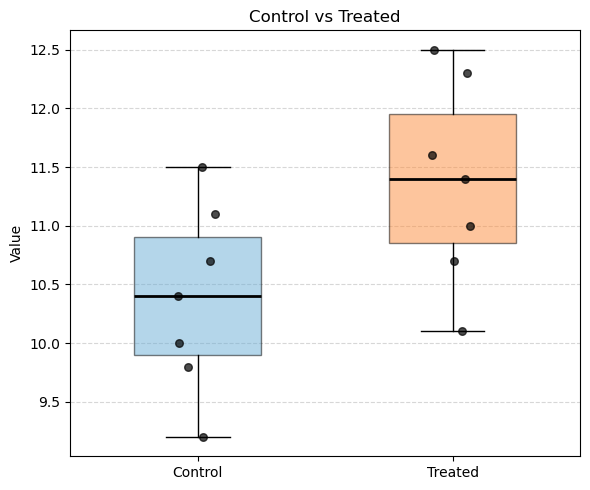

Difference in means: 0.9857
Standard error: 0.4403
t-statistic: 2.2387, df = 11.93
p-value (two-sided): 0.04504
95% CI: (0.0257, 1.9457)


In [ ]:
###
# Answers
###

#1. 
control = np.array([9.2, 9.8, 10.0, 10.4, 10.7, 11.1, 11.5])
treated = np.array([10.1, 10.7, 11.0, 11.4, 11.6, 12.3, 12.5])

fig, ax = plt.subplots(figsize=(6,5))
box = ax.boxplot([control, treated], labels=['Control', 'Treated'], patch_artist=True, widths=0.5, showfliers=False)

colors = ['#6baed6', '#fd8d3c']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# Overlay individual points with a bit of horizontal jitter so they don't overlap
rng = np.random.default_rng(0)
for i, data in enumerate([control, treated], start=1):
    jitter = rng.uniform(-0.08, 0.08, size=len(data))
    ax.scatter(np.full(len(data), i) + jitter, data, color='black', alpha=0.7, zorder=3, s=30)

ax.set_ylabel('Value')
ax.set_title('Control vs Treated')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#It's useful to show the individual observations as well to qualitatively analyze the spread of the data. The means only show the average of the data, but the individual points help answer questions about the spreads of the two groups, amount of overlap in ranges, and other details. 

#2.
n1, n2 = len(control), len(treated)
m1, m2 = control.mean(), treated.mean()
v1, v2 = control.var(ddof=1), treated.var(ddof=1)

diff = m2 - m1

se = np.sqrt(v1/n1 + v2/n2)
df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
t_stat = diff / se
p_value = 2 * stats.t.sf(np.abs(t_stat), df)
ci = (diff - stats.t.ppf(0.975, df)*se, diff + stats.t.ppf(0.975, df)*se)

print(f"Difference in means: {diff:.4f}")
print(f"Standard error: {se:.4f}")
print(f"t-statistic: {t_stat:.4f}, df = {df:.2f}")
print(f"p-value (two-sided): {p_value:.5f}")
print(f"95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")

#3.
#Null: There is no difference in expression between the control and treated groups, i.e. the difference in population means is 0.
#Alternative: There is a difference in expression between the control and treated groups, i.e. the difference in population means is not 0. 

#4.
#The probability is about 0.045, meaning that assuming the null hypothesis is true, the probability of observing values as or more extreme than what was actually observed is 0.045. It does not mean that the difference in mean observed has a probability of 0.045 of being correct, or that the probability of the null being true is 0.045. It only gives you the probability of seeing the observed result or one more extreme assuming the null is true.

#5.
#A confidence interval provides a range of possible differences in mean to consider and allows you to qualitatively analyze the uncertainty in the difference in means. A wide interval would suggest that there is a lot of noise in the data, whereas a narrower one might show you that the result might have more signal. These insights cannot be extracted from a simple significance label.

#6.
#Yes, the t-statistic captures the ratio of the signal to noise. The signal is the numerator, the difference in means, while the noise is the denominator, the SE. If the difference in means increases, the t-statistic also increases. This corresponds to a lower p-value. However, if the SE also increases, depending on how much it increases, it could drive down the t-statistic and result in a higher p-value. This would make it less significant. It depends on how much the factor of the increase in difference in means relative to the factor of increase in the SE.

#7.
#Determining whether the test should be one-sided or two sided is important to avoid biases when performing the significance test and maintain test relevance. Depending on the alternative hypothesis, we could be looking for any difference in the mean or looking for a difference in a certain direction. Choosing the test to align with the alternative hypothesis is important to maintain relevance. Also, people tend to want to look for significance, so choosing after examining the results introduces a sort of confirmation bias. 

#### **Questions:** Linear Models and Likelihood
1. Fit the model 𝑦𝑖 = 𝛽0 + 𝛽1𝑥𝑖 + 𝜀𝑖, 𝑥𝑖 = 0 for control and 𝑥𝑖 = 1 for treated. 

    What do 𝛽0 and 𝛽1 represent? Explain why testing 𝐻0 ∶ 𝛽1 = 0 asks the same scientific question as testing equal group means.

2. In one or two sentences, explain why maximizing a Gaussian likelihood with respect to 𝛽 is equivalent to minimizing
‖𝑦 − 𝑋𝛽‖22

3. Give two assumptions that make a two-sample 𝑡-test or Gaussian linear model more reliable. For each assumption, describe one possible consequence of violating it.

4. Why should a plot of the observations be part of the analysis before reporting a test statistic or 𝑝-value?

5. If the group indicator were coded as 𝑥𝑖 = 1 for control and 𝑥𝑖 = 0 for treated instead, how would the interpretations of 𝛽0 and 𝛽1 change?

6. What does a residual represent in a linear model? Give one example of a residual pattern that might suggest the model is inadequate.

In [ ]:
###
# Answers
###

import statsmodels.api as sm

#1.
y = np.concatenate([control, treated])
x = np.concatenate([np.zeros(len(control)), np.ones(len(treated))])

X = sm.add_constant(x)  # adds the intercept column
model = sm.OLS(y, X).fit()
print(model.summary())

#B0 represents the mean expression in control group while B1 represents the difference in expression from the control group in the treated group. Since B1 = 0 suggests there is no difference in expression between the control group and greatment group, testing for it asks the same scientific question as testing if the group means are equal.

#2.
#The model can be written as y = Xß + ε where ε ~ N(0, Isigma^2), and since the log-likelihood can be expressed as ‖𝑦 − 𝑋𝛽‖22, maximizing with Gaussian likelihood with respect to be ß means that the y - Xß vector is minimized in magnitude.

#3.
#One assumption of the two-sample t-test is that the two groups are normally distributed. If this assumption is violated, skewdness or heavy tails can influence means and variances by introducing more extreme values. Since significance tests rely on both of these metrics to determine significance, distortion of these values can throw off calculated values for p and CI and result in false results. Another assumption is that observations are independent. If they are not, this can result in variances that are lower than they should be, which would inflate the p-value and result in false positives (rejections of the null). 

#4.
#A plot of the observations is useful in qualitatively checking if the assumptions for the test hold, and that nothing seems unusual. Skews or abnormal distributions in the observations in the sample could help catch instances of broken assumptions that would render the test results unreliable. 

#5.
#In this case, the E[y | x0] = ß0 and E[y | x1] = B0 + B1 would imply that B0 represents the mean expression in the control group while B1 would refer to the difference in mean expression between the control group and the treated group. The only difference is that the baseline being compared to is the treated expression instead of the control expression. 

#6. 
#A residual represents the difference between the value predicted by a model and the value of the actual observation. One example of a residual pattern that would suggest the model was inadequate would be if the residuals appeared to increase as the expected values themselves increased. This would suggest that the observations might be better fitted by a non-linear model instead. 

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     5.012
Date:                Sat, 12 Sep 2026   Prob (F-statistic):             0.0449
Time:                        23:10:27   Log-Likelihood:                -16.072
No. Observations:                  14   AIC:                             36.14
Df Residuals:                      12   BIC:                             37.42
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.3857      0.311     33.357      0.0

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  res = hypotest_fun_out(*samples, **kwds)
